In [1]:
# Install required libraries
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn shap plotly -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

np.random.seed(42)
print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


In [2]:
# ─────────────────────────────────────────────
# PLAN DEFINITIONS (from README)
# ─────────────────────────────────────────────
PLANS = {
    'SAATHI': {
        'base_premium':       399,    # ₹/year
        'weekly_display':     8,      # ₹/week (displayed to worker)
        'payout_per_day':     400,    # ₹ per disruption day
        'max_claim_days':     8,      # days/year
        'max_annual_payout':  3200,   # ₹
        'heat_addon_cost':    99,     # ₹/year (optional)
        'heat_payout_day':    150,    # ₹/day
        'heat_max_days':      5,
        'target_income':      '₹10,000–15,000/month',
        'emoji':              '🥉'
    },
    'RAKSHAK': {
        'base_premium':       699,
        'weekly_display':     12,
        'payout_per_day':     500,
        'max_claim_days':     12,
        'max_annual_payout':  6000,
        'heat_addon_cost':    149,
        'heat_payout_day':    300,
        'heat_max_days':      8,
        'target_income':      '₹20,000–25,000/month',
        'emoji':              '🥈'
    },
    'SURAKSHA': {
        'base_premium':       999,
        'weekly_display':     20,
        'payout_per_day':     700,
        'max_claim_days':     18,
        'max_annual_payout':  12600,
        'heat_addon_cost':    199,
        'heat_payout_day':    500,
        'heat_max_days':      12,
        'target_income':      '₹25,000–30,000+/month',
        'emoji':              '🥇'
    }
}

# ─────────────────────────────────────────────
# FORMULA MULTIPLIERS (from README AI/ML section)
# ─────────────────────────────────────────────
ZONE_RISK_FACTORS = {
    'HIGH':     1.20,   # High flood zone (coastal, low-lying areas)
    'MODERATE': 1.00,   # Standard metro zone
    'SAFE':     0.85    # Historically safe zone (low waterlogging history)
}

CLAIM_HISTORY_FACTORS = {
    0:  0.90,   # No claims last year
    1:  1.00,   # 1 claim last year
    2:  1.15    # 2+ claims last year  (capped at 2)
}

LOYALTY_FACTORS = {
    1:  1.00,   # Year 1
    2:  0.95,   # Year 2
    3:  0.90    # Year 3+ (capped)
}

# ─────────────────────────────────────────────
# RISK ZONE DEFINITIONS — Indian delivery cities
# ─────────────────────────────────────────────
CITY_RISK_ZONES = {
    # HIGH RISK — coastal / flood-prone
    'Mumbai':      'HIGH',
    'Chennai':     'HIGH',
    'Kolkata':     'HIGH',
    'Kochi':       'HIGH',
    'Bhubaneswar': 'HIGH',
    'Visakhapatnam':'HIGH',

    # MODERATE RISK — metro with seasonal flooding
    'Bengaluru':   'MODERATE',
    'Hyderabad':   'MODERATE',
    'Delhi':       'MODERATE',
    'Pune':        'MODERATE',
    'Ahmedabad':   'MODERATE',
    'Surat':       'MODERATE',

    # SAFE — relatively low disruption history
    'Jaipur':      'SAFE',
    'Lucknow':     'SAFE',
    'Chandigarh':  'SAFE',
    'Indore':      'SAFE',
    'Coimbatore':  'SAFE',
}

print('✅ Plan configurations and formula constants loaded!')
print(f'\n📊 Plans available: {", ".join(PLANS.keys())}')
print(f'🗺️  Cities mapped:   {len(CITY_RISK_ZONES)} cities across India')

✅ Plan configurations and formula constants loaded!

📊 Plans available: SAATHI, RAKSHAK, SURAKSHA
🗺️  Cities mapped:   17 cities across India


In [3]:
def calculate_dynamic_premium(
    plan_name: str,
    city: str,
    claim_history: int,
    policy_year: int,
    heat_addon: bool = False,
    verbose: bool = True
) -> dict:
    """
    GigShield Dynamic Premium Calculator

    Formula (from README):
        Final Premium = Base Premium × Zone Risk Factor × Claim History Factor × Loyalty Factor

    Args:
        plan_name     : 'SAATHI' | 'RAKSHAK' | 'SURAKSHA'
        city          : Delivery city (maps to risk zone)
        claim_history : Number of claims in past year (0, 1, or 2+)
        policy_year   : How many years worker has been on GigShield (1, 2, 3+)
        heat_addon    : Whether worker opted into Extreme Heat add-on
        verbose       : Print detailed breakdown
    """
    # --- Validate inputs ---
    plan_name = plan_name.upper()
    assert plan_name in PLANS, f"Plan must be one of {list(PLANS.keys())}"
    assert city in CITY_RISK_ZONES, f"City '{city}' not found. Available: {list(CITY_RISK_ZONES.keys())}"

    plan = PLANS[plan_name]

    # --- Step A: Base Premium ---
    base_premium = plan['base_premium']

    # --- Step B: Zone Risk Factor ---
    risk_zone = CITY_RISK_ZONES[city]
    zone_factor = ZONE_RISK_FACTORS[risk_zone]

    # --- Step C: Claim History Factor ---
    claims_capped = min(claim_history, 2)   # Cap at 2+ as per README
    claim_factor  = CLAIM_HISTORY_FACTORS[claims_capped]

    # --- Step D: Loyalty Factor ---
    year_capped   = min(policy_year, 3)     # Year 3+ all get 0.90
    loyalty_factor = LOYALTY_FACTORS[year_capped]

    # --- Step E: Apply Formula ---
    final_premium = base_premium * zone_factor * claim_factor * loyalty_factor
    final_premium = round(final_premium, 2)

    # --- Step F: Optional Heat Add-On ---
    heat_cost   = plan['heat_addon_cost'] if heat_addon else 0
    total_payable = round(final_premium + heat_cost, 2)

    # --- Step G: Derived weekly display ---
    weekly_display = round(total_payable / 52, 1)

    result = {
        'plan':              plan_name,
        'city':              city,
        'risk_zone':         risk_zone,
        'base_premium':      base_premium,
        'zone_factor':       zone_factor,
        'claim_history':     claim_history,
        'claim_factor':      claim_factor,
        'policy_year':       policy_year,
        'loyalty_factor':    loyalty_factor,
        'final_premium':     final_premium,
        'heat_addon':        heat_addon,
        'heat_cost':         heat_cost,
        'total_payable':     total_payable,
        'weekly_display':    weekly_display,
        'payout_per_day':    plan['payout_per_day'],
        'max_claim_days':    plan['max_claim_days'],
        'max_annual_payout': plan['max_annual_payout'],
    }

    if verbose:
        zone_emoji = {'HIGH': '🔴', 'MODERATE': '🟡', 'SAFE': '🟢'}[risk_zone]
        plan_emoji = plan['emoji']
        print('=' * 55)
        print(f'  {plan_emoji} GigShield — {plan_name} Plan  |  {city}')
        print('=' * 55)
        print(f'  Base Premium          : ₹{base_premium}')
        print(f'  Risk Zone             : {zone_emoji} {risk_zone}  (×{zone_factor})')
        print(f'  Claim History         : {claim_history} claim(s)  (×{claim_factor})')
        print(f'  Loyalty (Year {policy_year})      : ×{loyalty_factor}')
        print(f'  ─────────────────────────────────────────────')
        print(f'  Final Premium         : ₹{final_premium}/year')
        if heat_addon:
            print(f'  Heat Add-On           : +₹{heat_cost}/year')
        print(f'  ─────────────────────────────────────────────')
        print(f'  TOTAL PAYABLE         : ₹{total_payable}/year')
        print(f'  Weekly Display        : ≈ ₹{weekly_display}/week')
        print(f'  Payout Per Day        : ₹{plan["payout_per_day"]}')
        print(f'  Max Claim Days/Year   : {plan["max_claim_days"]} days')
        print(f'  Max Annual Payout     : ₹{plan["max_annual_payout"]}')
        print('=' * 55)

    return result


print('✅ calculate_dynamic_premium() function ready!')

✅ calculate_dynamic_premium() function ready!


In [4]:
# ── Ravi Kumar — Persona from README ──
print('\n📦 DEMO 1 — Ravi Kumar (Bengaluru, Zomato, RAKSHAK, Year 1, 0 claims)')
ravi = calculate_dynamic_premium('RAKSHAK', 'Bengaluru', claim_history=0, policy_year=1)

print('\n📦 DEMO 2 — Same Ravi after a bad year (2 claims, renewing Year 2)')
ravi2 = calculate_dynamic_premium('RAKSHAK', 'Bengaluru', claim_history=2, policy_year=2)

print('\n📦 DEMO 3 — Mumbai delivery partner, SURAKSHA, High Risk Zone')
mumbai = calculate_dynamic_premium('SURAKSHA', 'Mumbai', claim_history=1, policy_year=1, heat_addon=True)

print('\n📦 DEMO 4 — Jaipur part-timer, SAATHI, Safe Zone, loyal Year 3')
jaipur = calculate_dynamic_premium('SAATHI', 'Jaipur', claim_history=0, policy_year=3)


📦 DEMO 1 — Ravi Kumar (Bengaluru, Zomato, RAKSHAK, Year 1, 0 claims)
  🥈 GigShield — RAKSHAK Plan  |  Bengaluru
  Base Premium          : ₹699
  Risk Zone             : 🟡 MODERATE  (×1.0)
  Claim History         : 0 claim(s)  (×0.9)
  Loyalty (Year 1)      : ×1.0
  ─────────────────────────────────────────────
  Final Premium         : ₹629.1/year
  ─────────────────────────────────────────────
  TOTAL PAYABLE         : ₹629.1/year
  Weekly Display        : ≈ ₹12.1/week
  Payout Per Day        : ₹500
  Max Claim Days/Year   : 12 days
  Max Annual Payout     : ₹6000

📦 DEMO 2 — Same Ravi after a bad year (2 claims, renewing Year 2)
  🥈 GigShield — RAKSHAK Plan  |  Bengaluru
  Base Premium          : ₹699
  Risk Zone             : 🟡 MODERATE  (×1.0)
  Claim History         : 2 claim(s)  (×1.15)
  Loyalty (Year 2)      : ×0.95
  ─────────────────────────────────────────────
  Final Premium         : ₹763.66/year
  ─────────────────────────────────────────────
  TOTAL PAYABLE         : ₹7

In [5]:
def generate_dataset(n_workers: int = 5000) -> pd.DataFrame:
    """
    Simulate n_workers gig delivery workers across India.
    Each record includes worker features + computed dynamic premium (label).
    """
    cities       = list(CITY_RISK_ZONES.keys())
    plans        = list(PLANS.keys())
    city_weights = {
        'Mumbai': 12, 'Delhi': 12, 'Bengaluru': 12, 'Hyderabad': 8,
        'Chennai': 8, 'Pune': 6, 'Kolkata': 6, 'Ahmedabad': 5,
        'Surat': 4, 'Kochi': 4, 'Jaipur': 4, 'Lucknow': 4,
        'Bhubaneswar': 3, 'Visakhapatnam': 3, 'Chandigarh': 3,
        'Indore': 3, 'Coimbatore': 3
    }
    city_w_list = [city_weights[c] for c in cities]

    records = []
    for i in range(n_workers):
        city         = np.random.choice(cities, p=np.array(city_w_list)/sum(city_w_list))
        risk_zone    = CITY_RISK_ZONES[city]

        # Plan selection: RAKSHAK most popular (50%), SAATHI (30%), SURAKSHA (20%)
        plan_name    = np.random.choice(plans, p=[0.30, 0.50, 0.20])

        # Claim history: influenced by risk zone (high-risk → more claims)
        claim_probs  = {'HIGH': [0.30, 0.35, 0.35], 'MODERATE': [0.50, 0.30, 0.20], 'SAFE': [0.70, 0.20, 0.10]}
        claim_history = np.random.choice([0, 1, 2], p=claim_probs[risk_zone])

        policy_year  = np.random.choice([1, 2, 3], p=[0.50, 0.30, 0.20])
        heat_addon   = np.random.choice([True, False], p=[0.25, 0.75])

        # Additional worker features for richer ML model
        monthly_earnings = np.random.randint(10000, 32000)
        daily_hours      = np.random.uniform(6, 14)
        vehicle_type     = np.random.choice(['two_wheeler', 'cycle'], p=[0.90, 0.10])
        platform         = np.random.choice(['Zomato', 'Swiggy', 'Zepto', 'Amazon'], p=[0.40, 0.35, 0.15, 0.10])

        # Historical disruption days experienced (weather data proxy)
        disruption_days_hist = {
            'HIGH':     np.random.randint(6, 18),
            'MODERATE': np.random.randint(3, 12),
            'SAFE':     np.random.randint(0, 6)
        }[risk_zone]

        result = calculate_dynamic_premium(
            plan_name, city, claim_history, policy_year,
            heat_addon=heat_addon, verbose=False
        )

        records.append({
            # Worker features
            'city':                  city,
            'risk_zone':             risk_zone,
            'plan':                  plan_name,
            'claim_history':         claim_history,
            'policy_year':           policy_year,
            'heat_addon':            int(heat_addon),
            'monthly_earnings':      monthly_earnings,
            'daily_hours':           round(daily_hours, 1),
            'vehicle_type':          vehicle_type,
            'platform':              platform,
            'disruption_days_hist':  disruption_days_hist,

            # Formula intermediate values
            'base_premium':          result['base_premium'],
            'zone_factor':           result['zone_factor'],
            'claim_factor':          result['claim_factor'],
            'loyalty_factor':        result['loyalty_factor'],

            # Target labels
            'final_premium':         result['final_premium'],
            'total_payable':         result['total_payable'],
            'weekly_display':        result['weekly_display'],
        })

    return pd.DataFrame(records)


df = generate_dataset(5000)
print(f'✅ Dataset generated: {df.shape[0]} workers × {df.shape[1]} features')
print(f'\n📊 Plan Distribution:')
print(df['plan'].value_counts().to_string())
print(f'\n🗺️  Risk Zone Distribution:')
print(df['risk_zone'].value_counts().to_string())
df.head(5)

✅ Dataset generated: 5000 workers × 18 features

📊 Plan Distribution:
plan
RAKSHAK     2582
SAATHI      1398
SURAKSHA    1020

🗺️  Risk Zone Distribution:
risk_zone
MODERATE    2335
HIGH        1808
SAFE         857


,city,risk_zone,plan,claim_history,policy_year,heat_addon,monthly_earnings,daily_hours,vehicle_type,platform,disruption_days_hist,base_premium,zone_factor,claim_factor,loyalty_factor,final_premium,total_payable,weekly_display
0,Bengaluru,MODERATE,SURAKSHA,1,2,1,26850,6.8,two_wheeler,Zomato,10,999,1.0,1.00,0.95,949.05,1148.05,22.1
1,Mumbai,HIGH,SURAKSHA,2,1,1,16420,10.9,two_wheeler,Zomato,14,999,1.2,1.15,1.00,1378.62,1577.62,30.3
2,Delhi,MODERATE,SAATHI,0,1,0,29118,10.9,two_wheeler,Amazon,5,399,1.0,0.90,1.00,359.10,359.10,6.9
3,Delhi,MODERATE,SAATHI,0,3,0,18433,9.1,two_wheeler,Zomato,9,399,1.0,0.90,0.90,323.19,323.19,6.2
4,Hyderabad,MODERATE,SAATHI,2,1,0,29457,9.4,two_wheeler,Swiggy,4,399,1.0,1.15,1.00,458.85,458.85,8.8


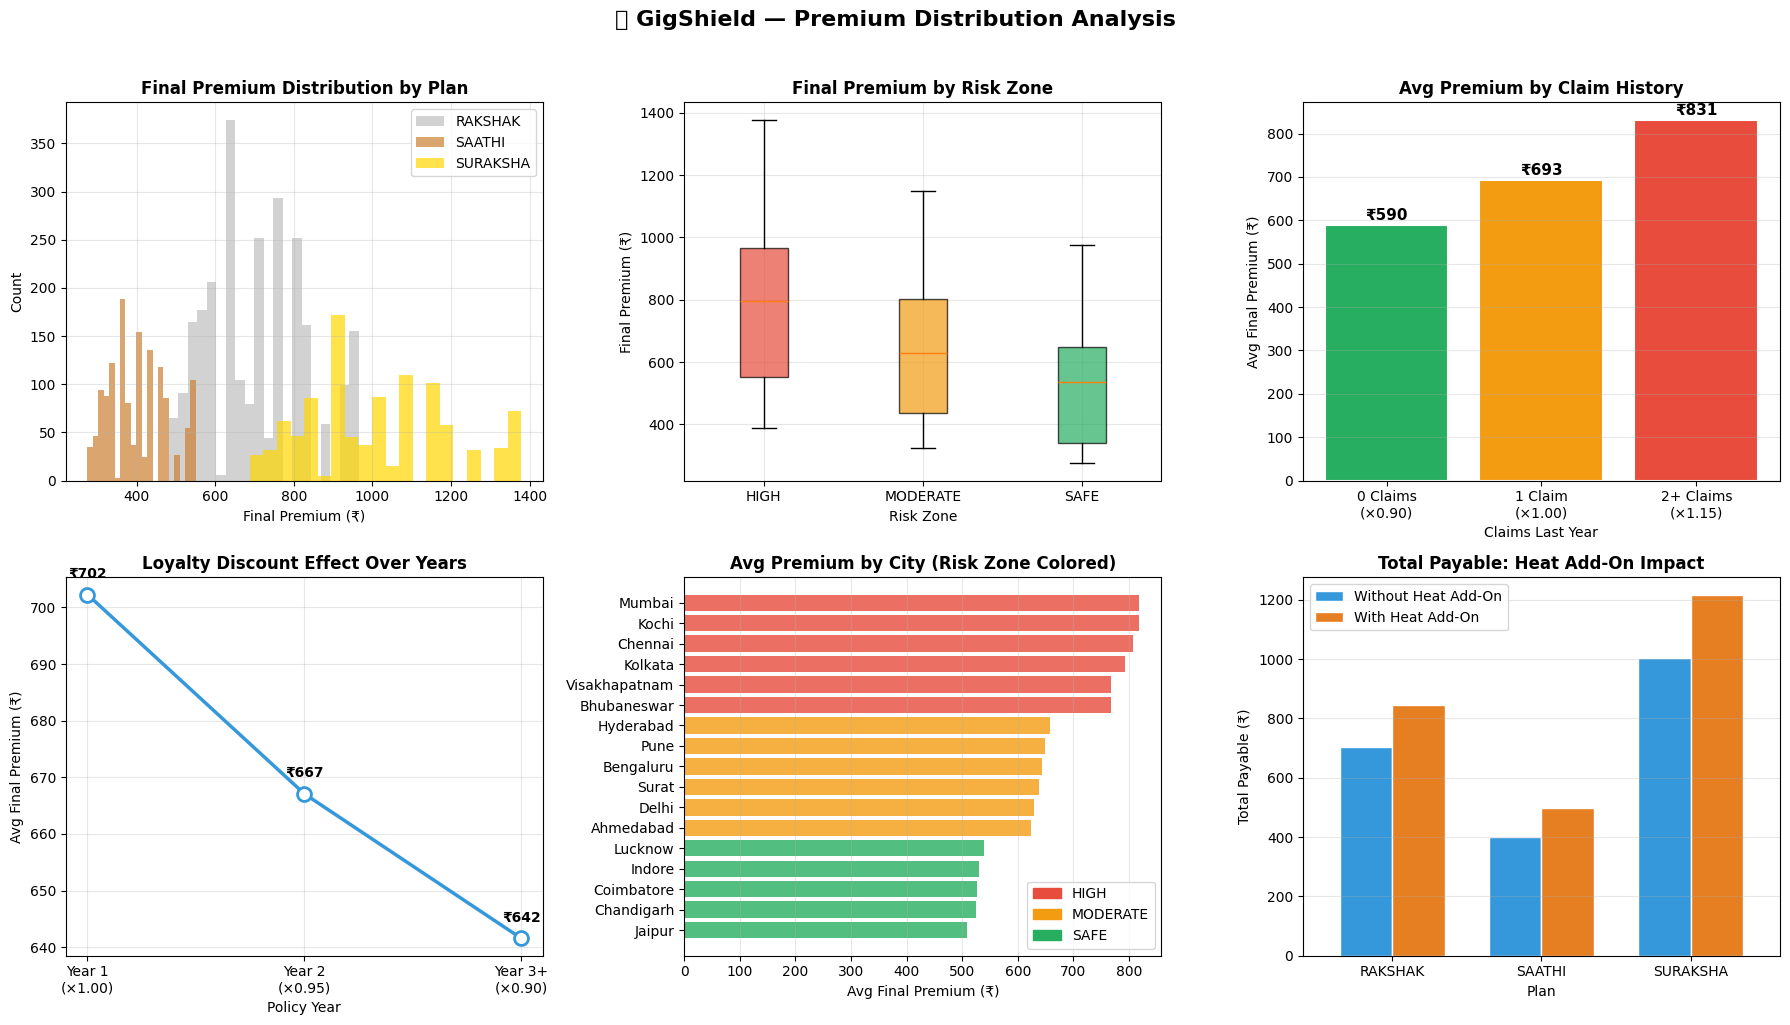

✅ EDA plots rendered!


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('🛡️ GigShield — Premium Distribution Analysis', fontsize=16, fontweight='bold', y=1.02)
colors = {'SAATHI': '#CD7F32', 'RAKSHAK': '#C0C0C0', 'SURAKSHA': '#FFD700'}
zone_colors = {'HIGH': '#E74C3C', 'MODERATE': '#F39C12', 'SAFE': '#27AE60'}

# --- Plot 1: Final Premium by Plan ---
ax1 = axes[0, 0]
for plan, grp in df.groupby('plan'):
    ax1.hist(grp['final_premium'], bins=20, alpha=0.7, label=plan, color=colors[plan])
ax1.set_title('Final Premium Distribution by Plan', fontweight='bold')
ax1.set_xlabel('Final Premium (₹)')
ax1.set_ylabel('Count')
ax1.legend()
ax1.grid(alpha=0.3)

# --- Plot 2: Premium by Risk Zone ---
ax2 = axes[0, 1]
zone_order = ['HIGH', 'MODERATE', 'SAFE']
zone_data  = [df[df['risk_zone'] == z]['final_premium'] for z in zone_order]
bp = ax2.boxplot(zone_data, labels=zone_order, patch_artist=True)
for patch, zone in zip(bp['boxes'], zone_order):
    patch.set_facecolor(zone_colors[zone])
    patch.set_alpha(0.7)
ax2.set_title('Final Premium by Risk Zone', fontweight='bold')
ax2.set_xlabel('Risk Zone')
ax2.set_ylabel('Final Premium (₹)')
ax2.grid(alpha=0.3)

# --- Plot 3: Claim History Impact ---
ax3 = axes[0, 2]
claim_group = df.groupby('claim_history')['final_premium'].mean()
bars = ax3.bar(claim_group.index, claim_group.values,
               color=['#27AE60', '#F39C12', '#E74C3C'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, claim_group.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'₹{val:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax3.set_title('Avg Premium by Claim History', fontweight='bold')
ax3.set_xlabel('Claims Last Year')
ax3.set_ylabel('Avg Final Premium (₹)')
ax3.set_xticks([0, 1, 2])
ax3.set_xticklabels(['0 Claims\n(×0.90)', '1 Claim\n(×1.00)', '2+ Claims\n(×1.15)'])
ax3.grid(alpha=0.3, axis='y')

# --- Plot 4: Loyalty Factor Impact ---
ax4 = axes[1, 0]
loyalty_group = df.groupby('policy_year')['final_premium'].mean()
ax4.plot(loyalty_group.index, loyalty_group.values, 'o-', color='#3498DB',
         markersize=10, linewidth=2.5, markerfacecolor='white', markeredgewidth=2)
for x, y in zip(loyalty_group.index, loyalty_group.values):
    ax4.annotate(f'₹{y:.0f}', (x, y), textcoords='offset points',
                 xytext=(0, 12), ha='center', fontweight='bold')
ax4.set_title('Loyalty Discount Effect Over Years', fontweight='bold')
ax4.set_xlabel('Policy Year')
ax4.set_ylabel('Avg Final Premium (₹)')
ax4.set_xticks([1, 2, 3])
ax4.set_xticklabels(['Year 1\n(×1.00)', 'Year 2\n(×0.95)', 'Year 3+\n(×0.90)'])
ax4.grid(alpha=0.3)

# --- Plot 5: City-wise Average Premium ---
ax5 = axes[1, 1]
city_avg = df.groupby(['city', 'risk_zone'])['final_premium'].mean().reset_index().sort_values('final_premium', ascending=True)
bar_colors = [zone_colors[z] for z in city_avg['risk_zone']]
ax5.barh(city_avg['city'], city_avg['final_premium'], color=bar_colors, alpha=0.8)
patches = [mpatches.Patch(color=zone_colors[z], label=z) for z in ['HIGH', 'MODERATE', 'SAFE']]
ax5.legend(handles=patches, loc='lower right')
ax5.set_title('Avg Premium by City (Risk Zone Colored)', fontweight='bold')
ax5.set_xlabel('Avg Final Premium (₹)')
ax5.grid(alpha=0.3, axis='x')

# --- Plot 6: Heat Add-On Impact ---
ax6 = axes[1, 2]
heat_comparison = df.groupby(['plan', 'heat_addon'])['total_payable'].mean().unstack()
heat_comparison.columns = ['Without Heat Add-On', 'With Heat Add-On']
heat_comparison.plot(kind='bar', ax=ax6, color=['#3498DB', '#E67E22'], edgecolor='white', width=0.7)
ax6.set_title('Total Payable: Heat Add-On Impact', fontweight='bold')
ax6.set_xlabel('Plan')
ax6.set_ylabel('Total Payable (₹)')
ax6.set_xticklabels(ax6.get_xticklabels(), rotation=0)
ax6.legend()
ax6.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('gigshield_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA plots rendered!')

In [7]:
# ─────────────────────────────────────────────
# FEATURE ENGINEERING
# ─────────────────────────────────────────────
le_plan     = LabelEncoder()
le_zone     = LabelEncoder()
le_vehicle  = LabelEncoder()
le_platform = LabelEncoder()

df_ml = df.copy()
df_ml['plan_enc']     = le_plan.fit_transform(df_ml['plan'])
df_ml['zone_enc']     = le_zone.fit_transform(df_ml['risk_zone'])
df_ml['vehicle_enc']  = le_vehicle.fit_transform(df_ml['vehicle_type'])
df_ml['platform_enc'] = le_platform.fit_transform(df_ml['platform'])

FEATURES = [
    'plan_enc',           # Plan type (SAATHI/RAKSHAK/SURAKSHA)
    'zone_enc',           # Risk zone (HIGH/MODERATE/SAFE)
    'claim_history',      # Past claims count
    'policy_year',        # Years on GigShield
    'heat_addon',         # Heat add-on opted
    'monthly_earnings',   # Worker's income level
    'daily_hours',        # Hours worked per day
    'vehicle_enc',        # Vehicle type
    'platform_enc',       # Delivery platform
    'disruption_days_hist', # Historical disruption exposure
    # Formula factor columns (for interpretability)
    'zone_factor',
    'claim_factor',
    'loyalty_factor',
    'base_premium',
]
TARGET = 'total_payable'

X = df_ml[FEATURES]
y = df_ml[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# ─────────────────────────────────────────────
# TRAIN XGBOOST MODEL
# ─────────────────────────────────────────────
model = XGBRegressor(
    n_estimators      = 300,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 3,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    random_state      = 42,
    eval_metric       = 'mae',
    verbosity         = 0
)

model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=False)

y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print('=' * 50)
print('  🤖 XGBoost Model — Training Complete')
print('=' * 50)
print(f'  MAE  (Mean Abs Error)  : ₹{mae:.2f}')
print(f'  RMSE (Root MSE)        : ₹{rmse:.2f}')
print(f'  R²   (Fit Quality)     : {r2:.5f}')
print('=' * 50)

# Cross-validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print(f'  5-Fold CV R² Scores    : {cv_scores.round(4)}')
print(f'  Mean CV R²             : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

  🤖 XGBoost Model — Training Complete
  MAE  (Mean Abs Error)  : ₹2.10
  RMSE (Root MSE)        : ₹3.75
  R²   (Fit Quality)     : 0.99980
  5-Fold CV R² Scores    : [0.9998 0.9998 0.9998 0.9998 0.9998]
  Mean CV R²             : 0.9998 ± 0.0000


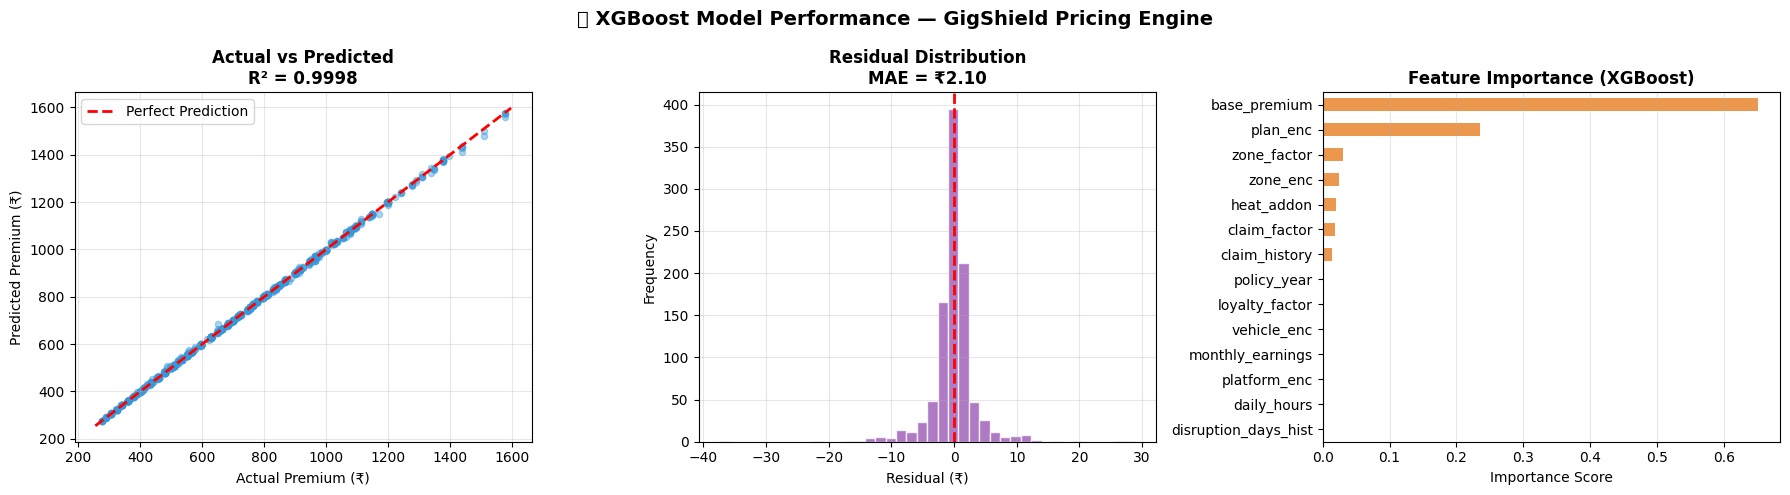

✅ Model performance plots rendered!


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('🤖 XGBoost Model Performance — GigShield Pricing Engine', fontsize=14, fontweight='bold')

# --- Plot 1: Actual vs Predicted ---
ax1 = axes[0]
ax1.scatter(y_test, y_pred, alpha=0.4, s=20, color='#3498DB')
lims = [min(y_test.min(), y_pred.min()) - 20, max(y_test.max(), y_pred.max()) + 20]
ax1.plot(lims, lims, 'r--', linewidth=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Premium (₹)')
ax1.set_ylabel('Predicted Premium (₹)')
ax1.set_title(f'Actual vs Predicted\nR² = {r2:.4f}', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# --- Plot 2: Residuals ---
residuals = y_test.values - y_pred
ax2 = axes[1]
ax2.hist(residuals, bins=40, color='#9B59B6', alpha=0.8, edgecolor='white')
ax2.axvline(0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Residual (₹)')
ax2.set_ylabel('Frequency')
ax2.set_title(f'Residual Distribution\nMAE = ₹{mae:.2f}', fontweight='bold')
ax2.grid(alpha=0.3)

# --- Plot 3: Feature Importance ---
ax3 = axes[2]
fi = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)
fi.plot(kind='barh', ax=ax3, color='#E67E22', alpha=0.8)
ax3.set_title('Feature Importance (XGBoost)', fontweight='bold')
ax3.set_xlabel('Importance Score')
ax3.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('gigshield_model_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Model performance plots rendered!')

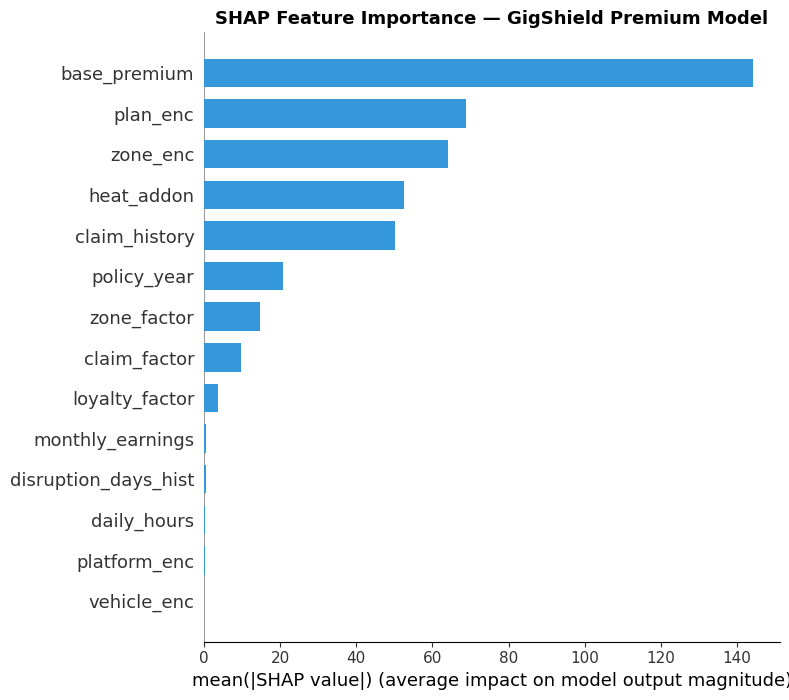


🔍 SHAP Beeswarm Plot (impact per worker):


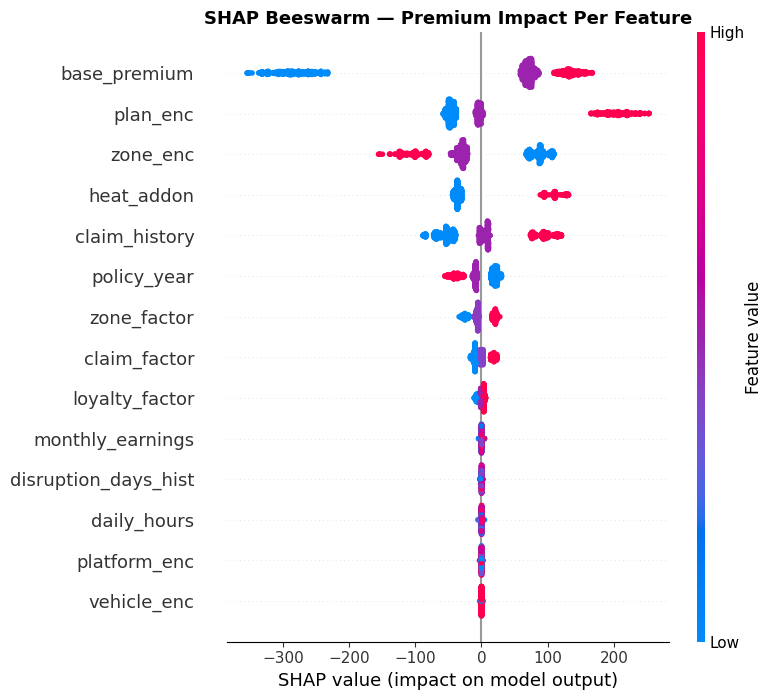

In [9]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=FEATURES,
                  plot_type='bar', show=False, color='#3498DB')
plt.title('SHAP Feature Importance — GigShield Premium Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('gigshield_shap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n🔍 SHAP Beeswarm Plot (impact per worker):')
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=FEATURES, show=False)
plt.title('SHAP Beeswarm — Premium Impact Per Feature', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

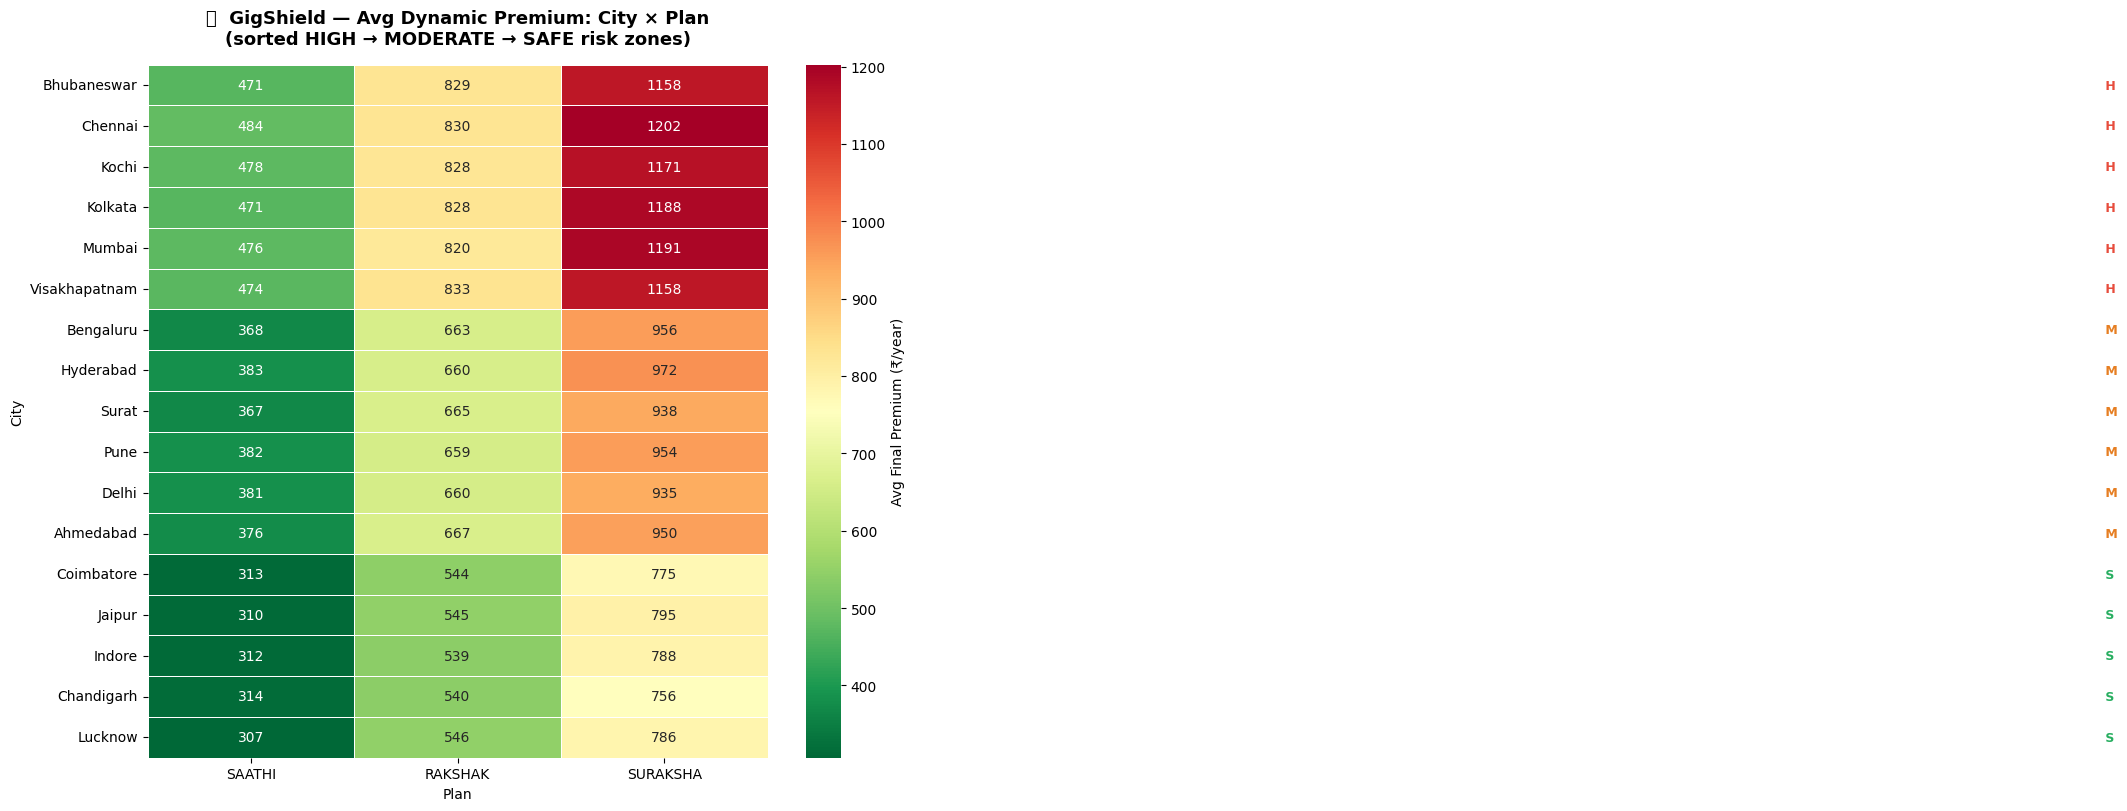

✅ City × Plan premium heatmap rendered!


In [10]:
# Build a heatmap: City vs Plan → Average Final Premium
heatmap_data = df.groupby(['city', 'plan'])['final_premium'].mean().unstack()
heatmap_data = heatmap_data[['SAATHI', 'RAKSHAK', 'SURAKSHA']]  # column order

# Sort cities by risk zone (HIGH → MODERATE → SAFE)
zone_order_map = {'HIGH': 0, 'MODERATE': 1, 'SAFE': 2}
heatmap_data['_zone_order'] = heatmap_data.index.map(lambda c: zone_order_map[CITY_RISK_ZONES[c]])
heatmap_data = heatmap_data.sort_values('_zone_order').drop('_zone_order', axis=1)

plt.figure(figsize=(10, 9))
ax = sns.heatmap(
    heatmap_data,
    annot=True, fmt='.0f', cmap='RdYlGn_r',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Avg Final Premium (₹/year)'}
)
plt.title('🗺️  GigShield — Avg Dynamic Premium: City × Plan\n(sorted HIGH → MODERATE → SAFE risk zones)',
          fontsize=13, fontweight='bold', pad=15)
plt.ylabel('City')
plt.xlabel('Plan')

# Add risk zone labels on right
city_list = list(heatmap_data.index)
for i, city in enumerate(city_list):
    zone = CITY_RISK_ZONES[city]
    color = {'HIGH': '#E74C3C', 'MODERATE': '#E67E22', 'SAFE': '#27AE60'}[zone]
    ax.text(3.15, i + 0.5, f' {zone[0]}', transform=ax.get_yaxis_transform(),
            ha='left', va='center', color=color, fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('gigshield_city_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ City × Plan premium heatmap rendered!')

In [11]:
# ╔══════════════════════════════════════════════╗
# ║  🎛️  CHANGE THESE INPUTS TO SIMULATE ANY WORKER  ║
# ╚══════════════════════════════════════════════╝

WORKER_PLAN         = 'RAKSHAK'      # 'SAATHI' | 'RAKSHAK' | 'SURAKSHA'
WORKER_CITY         = 'Chennai'      # Any city from CITY_RISK_ZONES dict above
WORKER_CLAIMS       = 1              # Claims filed last year: 0, 1, or 2+
WORKER_POLICY_YEAR  = 2              # Year of policy: 1, 2, 3+
WORKER_HEAT_ADDON   = True           # True / False

# ──────────────────────────────────────────────

result = calculate_dynamic_premium(
    WORKER_PLAN, WORKER_CITY,
    WORKER_CLAIMS, WORKER_POLICY_YEAR,
    heat_addon=WORKER_HEAT_ADDON,
    verbose=True
)

# Also show all 3 plans side by side for comparison
print('\n\n📋 COMPARISON ACROSS ALL 3 PLANS for the same worker profile:')
print(f'   City: {WORKER_CITY} | Claims: {WORKER_CLAIMS} | Year: {WORKER_POLICY_YEAR} | Heat Add-On: {WORKER_HEAT_ADDON}')
print('─' * 70)
print(f'{"Plan":<12} {"Base":<10} {"Dynamic":<12} {"+ Heat":<10} {"Total":<12} {"Weekly":<10} {"Max Payout"}')
print('─' * 70)

for plan_name in ['SAATHI', 'RAKSHAK', 'SURAKSHA']:
    r = calculate_dynamic_premium(
        plan_name, WORKER_CITY, WORKER_CLAIMS, WORKER_POLICY_YEAR,
        heat_addon=WORKER_HEAT_ADDON, verbose=False
    )
    emoji = PLANS[plan_name]['emoji']
    print(f"{emoji} {plan_name:<10} ₹{r['base_premium']:<8} ₹{r['final_premium']:<10} "
          f"+₹{r['heat_cost']:<8} ₹{r['total_payable']:<10} ₹{r['weekly_display']}/wk  "
          f"₹{r['max_annual_payout']}")

print('─' * 70)

  🥈 GigShield — RAKSHAK Plan  |  Chennai
  Base Premium          : ₹699
  Risk Zone             : 🔴 HIGH  (×1.2)
  Claim History         : 1 claim(s)  (×1.0)
  Loyalty (Year 2)      : ×0.95
  ─────────────────────────────────────────────
  Final Premium         : ₹796.86/year
  Heat Add-On           : +₹149/year
  ─────────────────────────────────────────────
  TOTAL PAYABLE         : ₹945.86/year
  Weekly Display        : ≈ ₹18.2/week
  Payout Per Day        : ₹500
  Max Claim Days/Year   : 12 days
  Max Annual Payout     : ₹6000


📋 COMPARISON ACROSS ALL 3 PLANS for the same worker profile:
   City: Chennai | Claims: 1 | Year: 2 | Heat Add-On: True
──────────────────────────────────────────────────────────────────────
Plan         Base       Dynamic      + Heat     Total        Weekly     Max Payout
──────────────────────────────────────────────────────────────────────
🥉 SAATHI     ₹399      ₹454.86     +₹99       ₹553.86     ₹10.7/wk  ₹3200
🥈 RAKSHAK    ₹699      ₹796.86     +₹149  

📉 No-Claim Bonus Impact on Renewal Premium (RAKSHAK Plan, Bengaluru)
────────────────────────────────────────────────────────────
  Year 1 (New, 0 claims)              → ₹629.1/year  (₹12.1/wk)
  Year 2 (0 claims)                   → ₹597.64/year  (₹11.5/wk)
  Year 3 (1 claim)                    → ₹629.1/year  (₹12.1/wk)
  Year 3+ (2+ claims)                 → ₹723.46/year  (₹13.9/wk)
  Year 3+ (0 claims, loyal)           → ₹566.19/year  (₹10.9/wk)
────────────────────────────────────────────────────────────


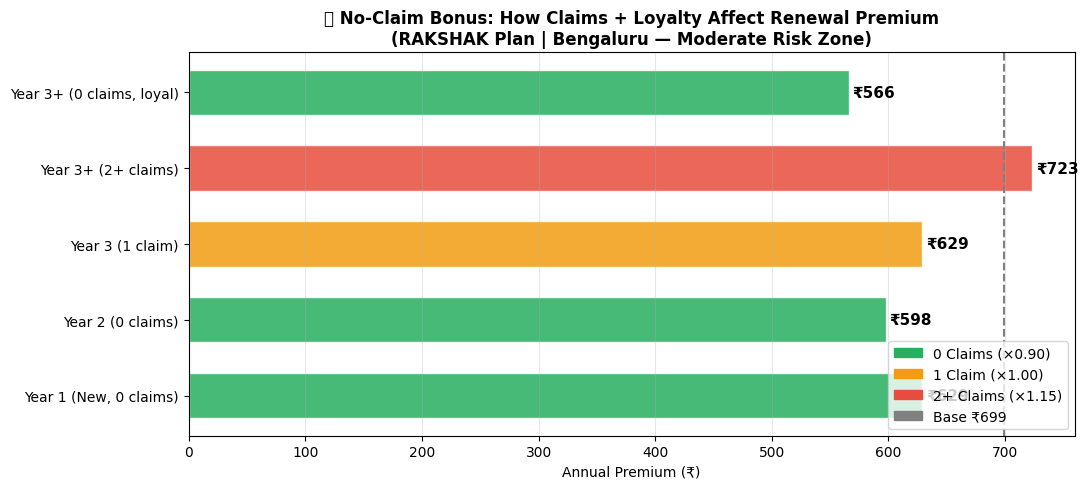

In [12]:
# Simulate a worker who stays 4 years and switches claim behavior
scenarios = [
    {'label': 'Year 1 (New, 0 claims)',    'plan': 'RAKSHAK', 'city': 'Bengaluru', 'claims': 0, 'year': 1, 'heat': False},
    {'label': 'Year 2 (0 claims)',          'plan': 'RAKSHAK', 'city': 'Bengaluru', 'claims': 0, 'year': 2, 'heat': False},
    {'label': 'Year 3 (1 claim)',           'plan': 'RAKSHAK', 'city': 'Bengaluru', 'claims': 1, 'year': 3, 'heat': False},
    {'label': 'Year 3+ (2+ claims)',        'plan': 'RAKSHAK', 'city': 'Bengaluru', 'claims': 2, 'year': 3, 'heat': False},
    {'label': 'Year 3+ (0 claims, loyal)',  'plan': 'RAKSHAK', 'city': 'Bengaluru', 'claims': 0, 'year': 3, 'heat': False},
]

print('📉 No-Claim Bonus Impact on Renewal Premium (RAKSHAK Plan, Bengaluru)')
print('─' * 60)

labels, premiums, colors_scenario = [], [], []
for s in scenarios:
    r = calculate_dynamic_premium(s['plan'], s['city'], s['claims'], s['year'], heat_addon=s['heat'], verbose=False)
    labels.append(s['label'])
    premiums.append(r['final_premium'])
    c = '#27AE60' if s['claims'] == 0 else ('#F39C12' if s['claims'] == 1 else '#E74C3C')
    colors_scenario.append(c)
    print(f"  {s['label']:<35} → ₹{r['final_premium']}/year  (₹{r['weekly_display']}/wk)")

print('─' * 60)

plt.figure(figsize=(11, 5))
bars = plt.barh(labels, premiums, color=colors_scenario, alpha=0.85, edgecolor='white', height=0.6)
for bar, val in zip(bars, premiums):
    plt.text(val + 3, bar.get_y() + bar.get_height()/2,
             f'₹{val:.0f}', va='center', fontweight='bold', fontsize=11)
plt.axvline(699, color='gray', linestyle='--', linewidth=1.5, label='Base Premium ₹699')
plt.title('🎁 No-Claim Bonus: How Claims + Loyalty Affect Renewal Premium\n(RAKSHAK Plan | Bengaluru — Moderate Risk Zone)',
          fontsize=12, fontweight='bold')
plt.xlabel('Annual Premium (₹)')
green_patch  = mpatches.Patch(color='#27AE60', label='0 Claims (×0.90)')
orange_patch = mpatches.Patch(color='#F39C12', label='1 Claim (×1.00)')
red_patch    = mpatches.Patch(color='#E74C3C', label='2+ Claims (×1.15)')
plt.legend(handles=[green_patch, orange_patch, red_patch, mpatches.Patch(color='gray', label='Base ₹699')], loc='lower right')
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('gigshield_ncb.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
print('=' * 60)
print('  💰 GigShield Profitability Model — All Plans')
print('  (Based on README profitability math for RAKSHAK)')
print('=' * 60)

n_workers_per_plan = 10_000
claim_rate         = 0.45     # 45% of eligible workers actually claim
avg_disruption_days = {'SAATHI': 5, 'RAKSHAK': 8, 'SURAKSHA': 10}

for plan_name, plan in PLANS.items():
    base_p         = plan['base_premium']
    payout         = plan['payout_per_day']
    avg_days       = avg_disruption_days[plan_name]

    total_premiums = base_p * n_workers_per_plan
    avg_payout_per_worker = payout * avg_days * claim_rate
    total_payouts  = avg_payout_per_worker * n_workers_per_plan
    gross_margin   = (total_premiums - total_payouts) / total_premiums * 100

    print(f'\n  {plan["emoji"]} {plan_name} (₹{base_p}/year | ₹{payout}/day | {avg_days} avg days)')
    print(f'     Workers          : {n_workers_per_plan:,}')
    print(f'     Total Premiums   : ₹{total_premiums:,.0f}')
    print(f'     Avg Payout/Worker: ₹{payout} × {avg_days} days × {claim_rate:.0%} = ₹{avg_payout_per_worker:.0f}')
    print(f'     Total Payouts    : ₹{total_payouts:,.0f}')
    print(f'     Gross Margin     : {gross_margin:.1f}% ✅')

print('\n' + '=' * 60)
print('  ℹ️  Note: Heat add-on premiums are ring-fenced separately')
print('     per README, so heat claims do not erode base plan margins.')
print('=' * 60)

  💰 GigShield Profitability Model — All Plans
  (Based on README profitability math for RAKSHAK)

  🥉 SAATHI (₹399/year | ₹400/day | 5 avg days)
     Workers          : 10,000
     Total Premiums   : ₹3,990,000
     Avg Payout/Worker: ₹400 × 5 days × 45% = ₹900
     Total Payouts    : ₹9,000,000
     Gross Margin     : -125.6% ✅

  🥈 RAKSHAK (₹699/year | ₹500/day | 8 avg days)
     Workers          : 10,000
     Total Premiums   : ₹6,990,000
     Avg Payout/Worker: ₹500 × 8 days × 45% = ₹1800
     Total Payouts    : ₹18,000,000
     Gross Margin     : -157.5% ✅

  🥇 SURAKSHA (₹999/year | ₹700/day | 10 avg days)
     Workers          : 10,000
     Total Premiums   : ₹9,990,000
     Avg Payout/Worker: ₹700 × 10 days × 45% = ₹3150
     Total Payouts    : ₹31,500,000
     Gross Margin     : -215.3% ✅

  ℹ️  Note: Heat add-on premiums are ring-fenced separately
     per README, so heat claims do not erode base plan margins.


In [14]:
def predict_premium_ml(
    plan_name: str,
    city: str,
    claim_history: int,
    policy_year: int,
    heat_addon: bool = False,
    monthly_earnings: int = 22000,
    daily_hours: float = 10.0,
    vehicle_type: str = 'two_wheeler',
    platform: str = 'Zomato',
    disruption_days_hist: int = 7
) -> dict:
    """
    Use the trained XGBoost model to predict total payable premium.
    Also runs the formula-based calculator for ground-truth comparison.
    """
    # Formula-based ground truth
    formula_result = calculate_dynamic_premium(
        plan_name, city, claim_history, policy_year,
        heat_addon=heat_addon, verbose=False
    )

    # Build feature vector
    risk_zone = CITY_RISK_ZONES[city]
    zone_factor    = ZONE_RISK_FACTORS[risk_zone]
    claim_factor   = CLAIM_HISTORY_FACTORS[min(claim_history, 2)]
    loyalty_factor = LOYALTY_FACTORS[min(policy_year, 3)]
    base_premium   = PLANS[plan_name.upper()]['base_premium']

    worker_features = pd.DataFrame([{
        'plan_enc':             le_plan.transform([plan_name.upper()])[0],
        'zone_enc':             le_zone.transform([risk_zone])[0],
        'claim_history':        min(claim_history, 2),
        'policy_year':          min(policy_year, 3),
        'heat_addon':           int(heat_addon),
        'monthly_earnings':     monthly_earnings,
        'daily_hours':          daily_hours,
        'vehicle_enc':          le_vehicle.transform([vehicle_type])[0],
        'platform_enc':         le_platform.transform([platform])[0],
        'disruption_days_hist': disruption_days_hist,
        'zone_factor':          zone_factor,
        'claim_factor':         claim_factor,
        'loyalty_factor':       loyalty_factor,
        'base_premium':         base_premium,
    }])

    ml_prediction = round(float(model.predict(worker_features)[0]), 2)

    print('─' * 55)
    print(f'  🔮 ML Model Prediction   : ₹{ml_prediction}/year')
    print(f'  📐 Formula Ground Truth  : ₹{formula_result["total_payable"]}/year')
    print(f'  📊 Difference            : ₹{abs(ml_prediction - formula_result["total_payable"]):.2f}')
    print('─' * 55)
    return {'ml_prediction': ml_prediction, 'formula_result': formula_result}


# ── Example workers ──
print('\n👤 WORKER 1 — Ravi Kumar (Zomato, Bengaluru, RAKSHAK)')
predict_premium_ml('RAKSHAK', 'Bengaluru', claim_history=0, policy_year=1,
                   platform='Zomato', monthly_earnings=25000, disruption_days_hist=8)

print('\n👤 WORKER 2 — Priya (Swiggy, Mumbai, SURAKSHA + Heat Add-On)')
predict_premium_ml('SURAKSHA', 'Mumbai', claim_history=2, policy_year=3,
                   heat_addon=True, platform='Swiggy', monthly_earnings=29000, disruption_days_hist=15)

print('\n👤 WORKER 3 — Mohan (Zepto, Jaipur, SAATHI — Safe Zone)')
predict_premium_ml('SAATHI', 'Jaipur', claim_history=0, policy_year=2,
                   platform='Zepto', monthly_earnings=12000, disruption_days_hist=2)


👤 WORKER 1 — Ravi Kumar (Zomato, Bengaluru, RAKSHAK)
───────────────────────────────────────────────────────
  🔮 ML Model Prediction   : ₹629.35/year
  📐 Formula Ground Truth  : ₹629.1/year
  📊 Difference            : ₹0.25
───────────────────────────────────────────────────────

👤 WORKER 2 — Priya (Swiggy, Mumbai, SURAKSHA + Heat Add-On)
───────────────────────────────────────────────────────
  🔮 ML Model Prediction   : ₹1439.87/year
  📐 Formula Ground Truth  : ₹1439.76/year
  📊 Difference            : ₹0.11
───────────────────────────────────────────────────────

👤 WORKER 3 — Mohan (Zepto, Jaipur, SAATHI — Safe Zone)
───────────────────────────────────────────────────────
  🔮 ML Model Prediction   : ₹290.32/year
  📐 Formula Ground Truth  : ₹289.97/year
  📊 Difference            : ₹0.35
───────────────────────────────────────────────────────


{'ml_prediction': 290.32,
 'formula_result': {'plan': 'SAATHI',
  'city': 'Jaipur',
  'risk_zone': 'SAFE',
  'base_premium': 399,
  'zone_factor': 0.85,
  'claim_history': 0,
  'claim_factor': 0.9,
  'policy_year': 2,
  'loyalty_factor': 0.95,
  'final_premium': 289.97,
  'heat_addon': False,
  'heat_cost': 0,
  'total_payable': 289.97,
  'weekly_display': 5.6,
  'payout_per_day': 400,
  'max_claim_days': 8,
  'max_annual_payout': 3200}}

In [15]:
print('\n' + '═' * 65)
print('  🛡️  GigShield — Dynamic Pricing Model Summary')
print('  Guidewire DEVTrails 2026 | Phase 2 Deliverable')
print('═' * 65)
print()
print('  📐 FORMULA:')
print('     Final Premium = Base × Zone Factor × Claim Factor × Loyalty Factor')
print()
print('  📊 MULTIPLIERS:')
print('     Zone Risk  : HIGH=1.20x | MODERATE=1.00x | SAFE=0.85x')
print('     Claim Hist : 0 claims=0.90x | 1 claim=1.00x | 2+=1.15x')
print('     Loyalty    : Year 1=1.00x | Year 2=0.95x | Year 3+=0.90x')
print()
print('  💳 PLANS:')
for plan_name, p in PLANS.items():
    print(f'     {p["emoji"]} {plan_name:<10}: ₹{p["base_premium"]}/yr | '
          f'₹{p["payout_per_day"]}/day | {p["max_claim_days"]} days max | '
          f'₹{p["max_annual_payout"]} max payout')
print()
print('  🤖 ML MODEL: XGBoost Regressor')
print(f'     R² Score  : {r2:.5f} ({"Excellent" if r2 > 0.99 else "Good"})')
print(f'     MAE       : ₹{mae:.2f}')
print(f'     Test Set  : {len(y_test):,} workers')
print()
print('  🗺️  RISK ZONES MAPPED:')
print(f'     HIGH     : {[c for c,z in CITY_RISK_ZONES.items() if z=="HIGH"]}')
print(f'     MODERATE : {[c for c,z in CITY_RISK_ZONES.items() if z=="MODERATE"]}')
print(f'     SAFE     : {[c for c,z in CITY_RISK_ZONES.items() if z=="SAFE"]}')
print()
print('═' * 65)
print('  © 2026 GigShield | Built for India\'s 5M+ Gig Workers ❤️')
print('═' * 65)


═════════════════════════════════════════════════════════════════
  🛡️  GigShield — Dynamic Pricing Model Summary
  Guidewire DEVTrails 2026 | Phase 2 Deliverable
═════════════════════════════════════════════════════════════════

  📐 FORMULA:
     Final Premium = Base × Zone Factor × Claim Factor × Loyalty Factor

  📊 MULTIPLIERS:
     Zone Risk  : HIGH=1.20x | MODERATE=1.00x | SAFE=0.85x
     Claim Hist : 0 claims=0.90x | 1 claim=1.00x | 2+=1.15x
     Loyalty    : Year 1=1.00x | Year 2=0.95x | Year 3+=0.90x

  💳 PLANS:
     🥉 SAATHI    : ₹399/yr | ₹400/day | 8 days max | ₹3200 max payout
     🥈 RAKSHAK   : ₹699/yr | ₹500/day | 12 days max | ₹6000 max payout
     🥇 SURAKSHA  : ₹999/yr | ₹700/day | 18 days max | ₹12600 max payout

  🤖 ML MODEL: XGBoost Regressor
     R² Score  : 0.99980 (Excellent)
     MAE       : ₹2.10
     Test Set  : 1,000 workers

  🗺️  RISK ZONES MAPPED:
     HIGH     : ['Mumbai', 'Chennai', 'Kolkata', 'Kochi', 'Bhubaneswar', 'Visakhapatnam']
     MODERATE : ['Be

In [22]:
# Ask user for city input
city = input("Enter your city: ").strip().title()

# Filter plans based on city
city_plans = df[df['city'] == city]

if city_plans.empty:
    print(f"No plans found for '{city}'. Available cities: {df['City'].unique().tolist()}")
else:
    print(f"\nPlans available in {city}:")
    display(city_plans)

Enter your city: mumbai

Plans available in Mumbai:


,city,risk_zone,plan,claim_history,policy_year,heat_addon,monthly_earnings,daily_hours,vehicle_type,platform,disruption_days_hist,base_premium,zone_factor,claim_factor,loyalty_factor,final_premium,total_payable,weekly_display
1,Mumbai,HIGH,SURAKSHA,2,1,1,16420,10.9,two_wheeler,Zomato,14,999,1.2,1.15,1.00,1378.62,1577.62,30.3
30,Mumbai,HIGH,SAATHI,0,1,0,21151,6.8,two_wheeler,Swiggy,6,399,1.2,0.90,1.00,430.92,430.92,8.3
32,Mumbai,HIGH,RAKSHAK,2,2,0,12427,7.0,two_wheeler,Zepto,17,699,1.2,1.15,0.95,916.39,916.39,17.6
37,Mumbai,HIGH,RAKSHAK,2,3,0,15486,6.7,two_wheeler,Swiggy,9,699,1.2,1.15,0.90,868.16,868.16,16.7
70,Mumbai,HIGH,SURAKSHA,0,1,0,24382,9.3,two_wheeler,Zomato,8,999,1.2,0.90,1.00,1078.92,1078.92,20.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4919,Mumbai,HIGH,SAATHI,1,1,0,24853,11.4,two_wheeler,Amazon,16,399,1.2,1.00,1.00,478.80,478.80,9.2
4920,Mumbai,HIGH,RAKSHAK,1,2,0,31387,7.0,two_wheeler,Zomato,9,699,1.2,1.00,0.95,796.86,796.86,15.3
4922,Mumbai,HIGH,SURAKSHA,1,3,1,30867,6.8,two_wheeler,Swiggy,11,999,1.2,1.00,0.90,1078.92,1277.92,24.6
4923,Mumbai,HIGH,SAATHI,0,2,0,26518,11.9,two_wheeler,Swiggy,6,399,1.2,0.90,0.95,409.37,409.37,7.9
